In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV
from function_future.margin_calculator import calculate_margin, get_instrument_info, get_first_trade_date, get_recent_activity

In [3]:
symbol_lst = ["A", "B", "C", "CS", "M", "Y", "P", "LH"]

In [4]:
init_money_lst = []
for symbol in symbol_lst:
    margin = calculate_margin(symbol, 10)
    info = get_instrument_info(symbol)
    first_date = get_first_trade_date(symbol)
    activity = get_recent_activity(symbol)
    print(f"\n品种: {symbol} ({info.get('name', 'N/A')})")
    print(f"  首个交易日: {first_date}")
    print(f"  95分位数价格: {info['price_95th']:.2f}")
    print(f"  合约乘数: {info['contract_multiplier']}")
    print(f"  保证金率: {info['margin_rate']:.2%}")
    print(f"  10手保证金: {margin:,.2f}")
    print(f"  40%保证金所需本金: {margin / 0.4:,.0f} ")
    # print(f"  交易所: {info['exchange']}")
    print(f"  分均持仓量: {activity['avg_open_interest']:,.0f}")
    print(f"  分均成交量: {activity['avg_volume']:,.0f}")
    print(f"  分均成交额: {activity['avg_turnover']:,.0f}")

    init_money_lst.append(int(margin / 0.4))


品种: A (豆一)
  首个交易日: 2021-02-02
  95分位数价格: 4889.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 34,223.00
  40%保证金所需本金: 85,558 
  分均持仓量: 209,595
  分均成交量: 438
  分均成交额: 19,168,073

品种: B (豆二)
  首个交易日: 2021-02-02
  95分位数价格: 3822.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 26,754.00
  40%保证金所需本金: 66,885 
  分均持仓量: 138,063
  分均成交量: 363
  分均成交额: 13,260,080

品种: C (玉米)
  首个交易日: 2021-02-02
  95分位数价格: 2406.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 16,842.00
  40%保证金所需本金: 42,105 
  分均持仓量: 1,016,129
  分均成交量: 1,534
  分均成交额: 35,053,002

品种: CS (玉米淀粉)
  首个交易日: 2021-02-02
  95分位数价格: 2773.00
  合约乘数: 10
  保证金率: 6.00%
  10手保证金: 16,638.00
  40%保证金所需本金: 41,595 
  分均持仓量: 205,226
  分均成交量: 339
  分均成交额: 8,850,757

品种: M (豆粕)
  首个交易日: 2021-02-02
  95分位数价格: 3092.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 21,644.00
  40%保证金所需本金: 54,110 
  分均持仓量: 2,009,609
  分均成交量: 3,007
  分均成交额: 88,908,296

品种: Y (豆油)
  首个交易日: 2021-02-02
  95分位数价格: 8642.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 60,494.00
  40%保证金所需本金: 151,235 
  分均持仓量: 591,099
  分均成交量: 878
 

In [5]:
initial_capital = dict(zip(symbol_lst, init_money_lst))
initial_capital

{'A': 85557,
 'B': 66885,
 'C': 42105,
 'CS': 41595,
 'M': 54110,
 'Y': 151235,
 'P': 196220,
 'LH': 456160}

In [6]:
weights = dict(zip(symbol_lst, [5_000_000 // x for x in init_money_lst]))
weights

{'A': 58, 'B': 74, 'C': 118, 'CS': 120, 'M': 92, 'Y': 33, 'P': 25, 'LH': 10}

In [7]:
train_label = 5
rtn_mul = 1

bt_params = (0.9, 0.5, 10, 5*465)
train_end_date = '2025-01-01'

In [8]:
def run_res(symbol, bt_params):
    folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = initial_capital[symbol]
    bt.fee = 0

    bt.load_factor(symbol, end_date=bt.window_end)
    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [9]:
merged_data_lst = Parallel(n_jobs=len(symbol_lst))(delayed(run_res)(symbol, bt_params)
                                                   for symbol in symbol_lst)

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
trading_hours ['09:00-11:30', '13:30-15:00']
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


100%|██████████| 109828/109828 [04:49<00:00, 379.51it/s]


In [15]:
def plot_all(symbol_lst, merged_data_lst, weights=None):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.rename(columns={'equity':symbol}, inplace=True)
        df = df.groupby('date').last()
        # 如果有权重配置，应用权重
        if weights and symbol in weights:
            df[symbol] = df[symbol] * weights[symbol]

        # df = df.iloc[:-30]

        pnl_ret.append(df)

    return pd.concat(pnl_ret,axis=1).ffill()#.iloc[:-20]

In [16]:
merged_df_all = plot_all(symbol_lst, merged_data_lst, weights=weights)
merged_df_all

,A,B,C,CS,M,Y,P,LH
date,,,,,,,,
2025-01-02,4.927417e+06,4.906050e+06,5.145771e+06,5.115540e+06,4.983600e+06,5.236679e+06,5.197762e+06,4.554913e+06
2025-01-03,5.030038e+06,4.945776e+06,5.206539e+06,5.298293e+06,5.019908e+06,5.343226e+06,5.132310e+06,4.668950e+06
2025-01-06,5.196157e+06,4.847988e+06,5.260617e+06,5.178568e+06,5.320277e+06,5.333602e+06,5.153891e+06,4.595723e+06
2025-01-07,5.258359e+06,4.876362e+06,5.471601e+06,5.281319e+06,5.339162e+06,5.210049e+06,5.207626e+06,4.790560e+06
2025-01-08,5.260429e+06,5.044361e+06,5.479083e+06,5.423809e+06,5.368178e+06,5.103464e+06,5.379422e+06,4.669932e+06
...,...,...,...,...,...,...,...,...
2026-04-29,7.096021e+06,1.448389e+07,2.186408e+07,1.370362e+07,1.367606e+07,6.716727e+06,8.168116e+06,1.674967e+07
2026-04-30,7.157555e+06,1.457928e+07,2.187780e+07,1.369476e+07,1.374003e+07,6.660887e+06,8.019231e+06,1.682732e+07
2026-05-06,6.460879e+06,1.448281e+07,2.152481e+07,1.366605e+07,1.354777e+07,6.539427e+06,8.323516e+06,1.681125e+07


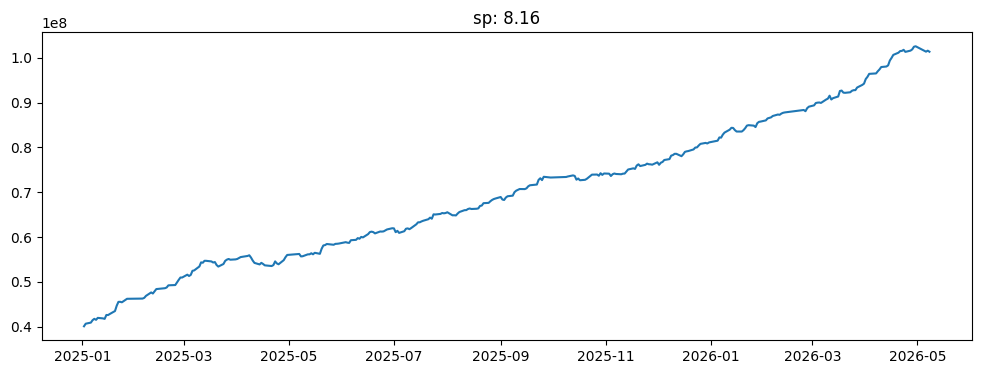

In [17]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()

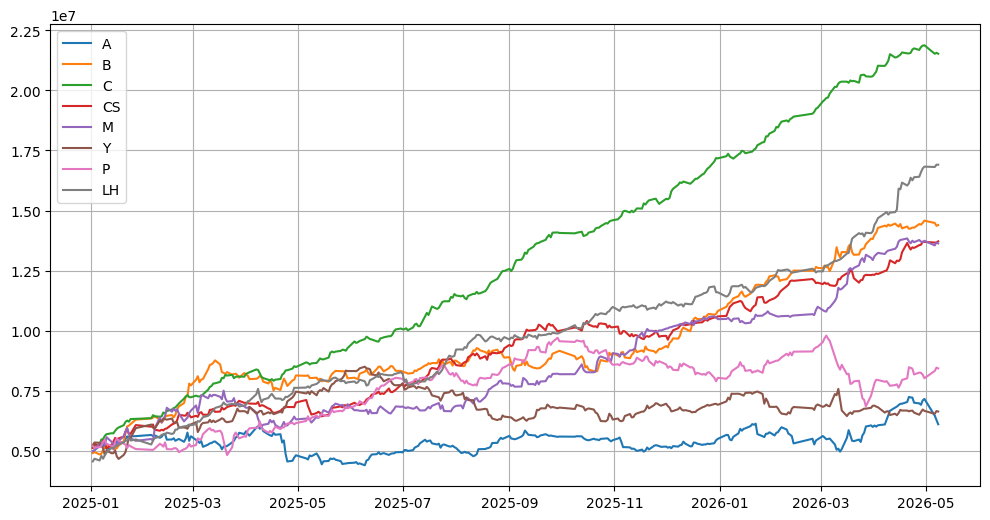

In [18]:
fig = plt.figure(figsize=(12, 6))
plt.plot(merged_df_all)
plt.legend(symbol_lst)
plt.grid()
plt.show()

In [14]:
res = pd.concat((bv.analyze_pos_distribution(merged_data_lst[i]) for i in range(len(symbol_lst))), axis=1)
res.columns = symbol_lst
res

,A,B,C,CS,M,Y,P,LH
多头(+1) 数量,23508,25932,22694,24424,23467,20661,23967,14070
空头(-1) 数量,21535,20775,21800,19817,22211,24816,20912,15788
空仓(0) 数量,64787,63123,65336,65589,64152,64353,64951,42412
多头占比,21.40%,23.61%,20.66%,22.24%,21.37%,18.81%,21.82%,19.47%
空头占比,19.61%,18.92%,19.85%,18.04%,20.22%,22.59%,19.04%,21.85%
空仓占比,58.99%,57.47%,59.49%,59.72%,58.41%,58.59%,59.14%,58.69%
交易日数量,324,324,324,324,324,324,324,322
总收益(非年化%),23.01,190.84,333.27,174.83,173.77,32.91,71.82,270.65
总交易次数（开平算一次）,2917,4874,5667,6705,2885,4519,3513,3087
日均交易次数（开平算一次）,9.00,15.04,17.49,20.69,8.90,13.95,10.84,9.59
